In [1]:
import shutil
from pathlib import Path

import lancedb
from lancedb.rerankers import ColbertReranker

from rag_app import add_data, application, get_user_query

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LANCE_URI = "lance/rag/"
if Path(LANCE_URI).exists():
    shutil.rmtree(LANCE_URI)

In [3]:
lance_db = lancedb.connect(uri=LANCE_URI)
reranker = ColbertReranker("answerdotai/answerai-colbert-small-v1")
data_path = "rag_data"

In [4]:
table_descriptions = add_data(lance_db=lance_db, data_path=data_path)

/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
table_descriptions

[TableDescription(name='Soccer', description='This database provides a comprehensive guide to the sport of soccer, covering basic rules, player positions, gameplay, fouls, set pieces, formations, and major competitions, along with a glossary of common terms. It is a valuable resource for both beginners and experienced fans.'),
 TableDescription(name='Finance', description='This database contains a comprehensive guide to personal finance, covering essential topics such as budgeting, saving, investing, insurance, tax planning, retirement planning, and estate planning. It provides practical tips, strategies, and explanations of key concepts, making it a valuable resource for individuals seeking to manage their finances effectively and achieve their financial goals.')]

In [6]:
app = application(
    db=lance_db, reranker=reranker, table_descriptions=table_descriptions, has_web=True
)

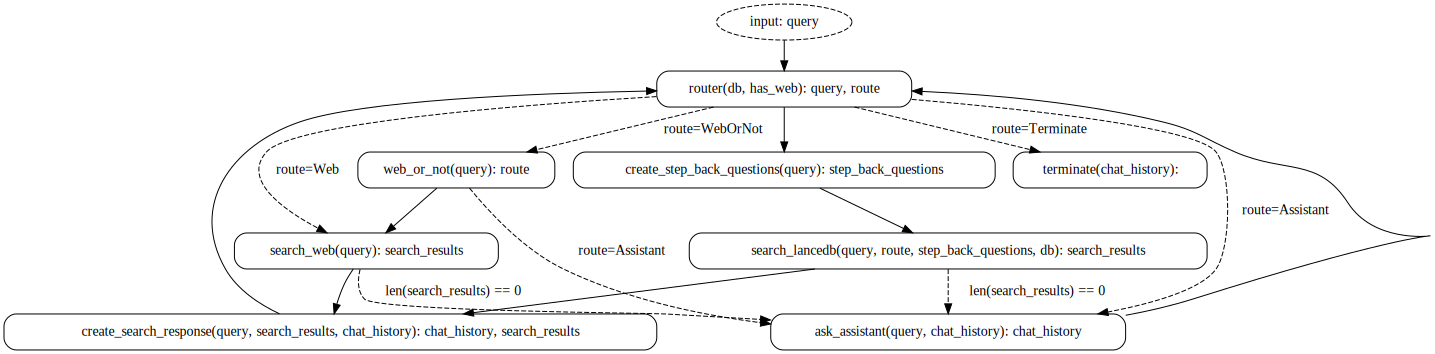

In [7]:
app.visualize(
    output_file_path="statemachine",
    include_conditions=True,
    include_state=True,
    format="png",
)

In [8]:
inputs = {"query": get_user_query()}
while True:
    action, result, state = app.step(inputs=inputs)  # type:ignore
    print(f"\nRESULT: {result}\n")
    if action.name == "terminate":
        break
    elif action.name in ["ask_assistant", "create_search_response"]:
        inputs["query"] = get_user_query()


RESULT: {'route': 'Soccer'}


RESULT: {'step_back_questions': ['What are the rules governing penalties in the sport in question?', 'What actions or events lead to a penalty being awarded in different sports?']}



/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



RESULT: {'search_results': ['## 6. Fouls and Misconduct\nUnderstanding fouls and misconduct is crucial in soccer. These rules ensure fair play\nand player safety.\n1. **Direct Free Kick Fouls**:\n  - Kicking or attempting to kick an opponent\n  - Tripping or attempting to trip an opponent\n  - Jumping at an opponent\n  - Charging an opponent\n  - Striking or attempting to strike an opponent\n  - Pushing an opponent\n  - Tackling an opponent to gain possession of the ball, making contact with the\nopponent before touching the ball\n  - Holding an opponent\n  - Spitting at an opponent\n  - Handling the ball deliberately (except for the goalkeeper within their penalty\narea)\n2. **Indirect Free Kick Fouls', "**Indirect Free Kick Fouls**:\n  - Playing in a dangerous manner\n  - Impeding the progress of an opponent without contact\n  - Preventing the goalkeeper from releasing the ball from their hands\n  - Goalkeeper handling offenses (e.g., handling a back-pass from a teammate)\n3. **Yell

/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



RESULT: {'search_results': ['## 11.2 Pay Yourself First\nMake saving and investing a priority by treating them as non-negotiable expenses.\n- **Automate savings**: Set up automatic transfers to savings and investment accounts.\n- **Increase savings with income**: When you get a raise, increase your savings rate\nbefore lifestyle inflation sets in.\n- **Use tax-advantaged accounts**: Maximize contributions to 401(k)s, IRAs, and HSAs\nwhere possible.', '## 7.2 Retirement Account Options\n1. **Employer-sponsored plans**:\n  - 401(k), 403(b), 457 plans\n  - Pension plans (defined benefit plans)\n2. **Individual Retirement Accounts (IRAs)**:\n  - Traditional IRA\n  - Roth IRA\n  - SEP IRA and SIMPLE IRA (for self-employed individuals and small businesses)\n3. **Taxable investment accounts**: While not specifically for retirement, these can\nsupplement retirement savings.\n4. **Annuities**: Can provide a steady stream of income in retirement.', "## 4.2 Retirement Savings\nSaving for retirem

In [10]:
app.state["chat_history"]

[{'role': 'user', 'content': 'when is a penalty awarded?'},
 {'role': 'assistant',
  'content': 'A penalty kick is awarded when a player commits a direct free kick offense inside their own penalty area.'},
 {'role': 'user', 'content': 'how to I save up for retirement?'},
 {'role': 'assistant',
  'content': "- Saving for retirement is a long-term goal that requires consistent effort throughout your working years. [2]\n- Start saving early to take advantage of the power of compound interest, which can significantly increase your retirement nest egg. [2]\n- Maximize contributions to employer-sponsored plans, especially if your employer offers matching contributions. [2]\n- Consider traditional or Roth IRAs for additional tax-advantaged retirement savings. [2]\n- If you're 50 or older, take advantage of catch-up contributions to boost your retirement savings. [2]"}]